# Micro Proyecto 1 — Generación de Música con LSTM
Compositor seleccionado: **Ludwig van Beethoven**

In [3]:
# ── Bandera de entorno ─────────────────────────────────────────────────────
# False → corre en local con los paths relativos del repo
# True  → corre en Google Colab con Google Drive montado
COLAB = True

if COLAB:
    
    from google.colab import drive
    drive.mount('/content/drive')

    !pip install pretty_midi


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 66.0 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.0 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=54a8115962926f100c22513a75097558a6cc958fd094b441d9cb3ae277b995d1
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [4]:
import pretty_midi
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygame
import time
import torch
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
torch.manual_seed(42)

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


## 1. Leer los archivos MIDI de Beethoven

In [5]:
if COLAB:
    # Google Drive: MyDrive/MASTER NLP_2/Microproyecto_1/data/music_artist/beeth
    DATA_PATH = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1/data/music_artist/beeth'
else:
    # Local: path relativo al notebook
    DATA_PATH = './data/music_artist/beeth'

midi_files = sorted([os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.mid')])
print(f'Archivos encontrados: {len(midi_files)}')
for i, f in enumerate(midi_files):
    print(f'  [{i}] {os.path.basename(f)}')

Archivos encontrados: 29
  [0] appass_1.mid
  [1] appass_2.mid
  [2] appass_3.mid
  [3] beethoven_hammerklavier_1.mid
  [4] beethoven_hammerklavier_2.mid
  [5] beethoven_hammerklavier_3.mid
  [6] beethoven_hammerklavier_4.mid
  [7] beethoven_les_adieux_1.mid
  [8] beethoven_les_adieux_2.mid
  [9] beethoven_les_adieux_3.mid
  [10] beethoven_opus10_1.mid
  [11] beethoven_opus10_2.mid
  [12] beethoven_opus10_3.mid
  [13] beethoven_opus22_1.mid
  [14] beethoven_opus22_2.mid
  [15] beethoven_opus22_3.mid
  [16] beethoven_opus22_4.mid
  [17] beethoven_opus90_1.mid
  [18] beethoven_opus90_2.mid
  [19] elise.mid
  [20] mond_1.mid
  [21] mond_2.mid
  [22] mond_3.mid
  [23] pathetique_1.mid
  [24] pathetique_2.mid
  [25] pathetique_3.mid
  [26] waldstein_1.mid
  [27] waldstein_2.mid
  [28] waldstein_3.mid


## 2. Escuchar un archivo

In [6]:
def play_midi(filepath, seconds=15):
    """Reproduce un archivo MIDI durante 'seconds' segundos."""
    pygame.mixer.init()
    pygame.mixer.music.load(filepath)
    pygame.mixer.music.play()
    print(f'Reproduciendo: {os.path.basename(filepath)} ({seconds}s)...')
    time.sleep(seconds)
    pygame.mixer.music.stop()
    print('Listo.')

if not COLAB:
    play_midi(midi_files[27], seconds=5)

## 3. Explorar un archivo

In [7]:
pm = pretty_midi.PrettyMIDI(midi_files[0])

print(f'Archivo: {os.path.basename(midi_files[0])}')
print(f'Duración: {pm.get_end_time():.2f} segundos')
print(f'Número de instrumentos: {len(pm.instruments)}')

for i, instrument in enumerate(pm.instruments):
    instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
    print(f'  Instrumento {i}: {instrument_name} — {len(instrument.notes)} notas')

Archivo: appass_1.mid
Duración: 558.90 segundos
Número de instrumentos: 2
  Instrumento 0: Acoustic Grand Piano — 3207 notas
  Instrumento 1: Acoustic Grand Piano — 3170 notas


In [8]:
instrument = pm.instruments[0]
instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
notes = sorted(instrument.notes, key=lambda x: x.start)

print(f'Instrumento: {instrument_name}')
print(f'\nPrimeras 10 notas (características de entrenamiento):')
print(f'{"pitch":>8} {"step":>10} {"duration":>10} {"velocity":>10}')

prev_start = None
for note in notes[:10]:
    step = note.start - prev_start if prev_start is not None else 0.0
    duration = note.end - note.start
    print(f'{note.pitch:>8} {step:>10.3f} {duration:>10.3f} {note.velocity:>10}')
    prev_start = note.start

Instrumento: Acoustic Grand Piano

Primeras 10 notas (características de entrenamiento):
   pitch       step   duration   velocity
      60      0.000      0.519         35
      56      0.519      0.137         31
      53      0.137      1.669         28
      56      1.669      0.477         35
      60      0.477      0.107         30
      65      0.107      0.528         35
      68      0.528      0.468         35
      72      0.468      0.102         30
      77      0.102      0.559         35
      65      0.567      0.556         33


## 4. Extraer las características de todos los archivos

Por cada nota extraemos:
- **pitch**: nota musical (categórica)
- **step**: tiempo desde la nota anterior (start_actual - start_anterior)
- **duration**: duración de la nota (end - start)
- **velocity**: velocidad de la nota (numérica)

In [9]:
TARGET_INSTRUMENT = 'Acoustic Grand Piano'

def extract_notes(instrument):
    notes = sorted(instrument.notes, key=lambda x: x.start)
    rows = []
    prev_start = None
    for note in notes:
        duration = note.end - note.start
        step = note.start - prev_start if prev_start is not None else 0.0
        rows.append({'pitch': note.pitch, 'step': step, 'duration': duration, 'velocity': note.velocity})
        prev_start = note.start
    return rows

all_notes = []
sequences      = []  # DataFrames de notas
sequence_names = []  # nombre de archivo por secuencia

for mid, f in enumerate(midi_files):
    pm = pretty_midi.PrettyMIDI(f)
    for i, instrument in enumerate(pm.instruments):
        inst_name = pretty_midi.program_to_instrument_name(instrument.program)
        if inst_name != TARGET_INSTRUMENT:
            continue
        notes = extract_notes(instrument)
        seq_df = pd.DataFrame(notes)
        sequences.append(seq_df)
        sequence_names.append(f'{os.path.basename(f)} — inst {i}')
        all_notes.extend(notes)
        if mid < 3:
            print(f'{os.path.basename(f)} — instrumento {i} ({inst_name}): {len(notes)} notas')

df = pd.DataFrame(all_notes)
print(f'\nTotal de secuencias: {len(sequences)}')
print(f'Total de notas: {len(df)}')
df.head(10)


appass_1.mid — instrumento 0 (Acoustic Grand Piano): 3207 notas
appass_1.mid — instrumento 1 (Acoustic Grand Piano): 3170 notas
appass_2.mid — instrumento 0 (Acoustic Grand Piano): 1128 notas
appass_2.mid — instrumento 1 (Acoustic Grand Piano): 853 notas
appass_3.mid — instrumento 0 (Acoustic Grand Piano): 3742 notas
appass_3.mid — instrumento 1 (Acoustic Grand Piano): 3481 notas

Total de secuencias: 47
Total de notas: 84785


,pitch,step,duration,velocity
0,60,0.000000,0.518640,35
1,56,0.518640,0.136599,31
2,53,0.136599,1.669347,28
3,56,1.669347,0.477331,35
4,60,0.477331,0.107427,30
5,65,0.107427,0.528293,35
6,68,0.528293,0.468093,35
7,72,0.468093,0.101550,30
8,77,0.101550,0.558752,35
9,65,0.566917,0.556449,33


## 5. Análisis Exploratorio de Datos (EDA)

In [10]:
# --- 5.1 Instrumentos por archivo ---
print(f'{"Archivo":<35} {"N° inst":>7}  Instrumentos')
print('-' * 70)

instrument_types = []
for f in midi_files:
    pm_f = pretty_midi.PrettyMIDI(f)
    names = [pretty_midi.program_to_instrument_name(inst.program) for inst in pm_f.instruments]
    instrument_types.extend(names)
    print(f'{os.path.basename(f):<35} {len(pm_f.instruments):>7}  {", ".join(names)}')

print(f'\nTipos de instrumento únicos: {set(instrument_types)}')
print(f'Total de archivos: {len(midi_files)}')
print(f'Total de secuencias (archivos x instrumentos): {len(sequences)}')

Archivo                             N° inst  Instrumentos
----------------------------------------------------------------------
appass_1.mid                              2  Acoustic Grand Piano, Acoustic Grand Piano
appass_2.mid                              2  Acoustic Grand Piano, Acoustic Grand Piano
appass_3.mid                              2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_1.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_2.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_3.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_4.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_les_adieux_1.mid                2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_les_adieux_2.mid                2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_les_adieux_3.mid                2  Acoustic Grand Piano, Acoustic Gra

In [11]:
# --- 5.2 Notas totales y por secuencia ---
notes_per_seq = [len(s) for s in sequences]

print(f'Total de notas en el dataset:      {len(df):,}')
print(f'Notas únicas (pitch distintos):    {df["pitch"].nunique()}  (pitch {df["pitch"].min()} – {df["pitch"].max()})')
print(f'\nNotas por secuencia:')
print(f'  Mínimo:   {min(notes_per_seq):,}')
print(f'  Máximo:   {max(notes_per_seq):,}')
print(f'  Promedio: {np.mean(notes_per_seq):,.1f}')

durations_sec = [pretty_midi.PrettyMIDI(f).get_end_time() for f in midi_files]
print(f'\nDuración total acumulada: {sum(durations_sec)/60:.1f} minutos')

Total de notas en el dataset:      84,785
Notas únicas (pitch distintos):    78  (pitch 24 – 101)

Notas por secuencia:
  Mínimo:   118
  Máximo:   4,499
  Promedio: 1,803.9

Duración total acumulada: 182.4 minutos


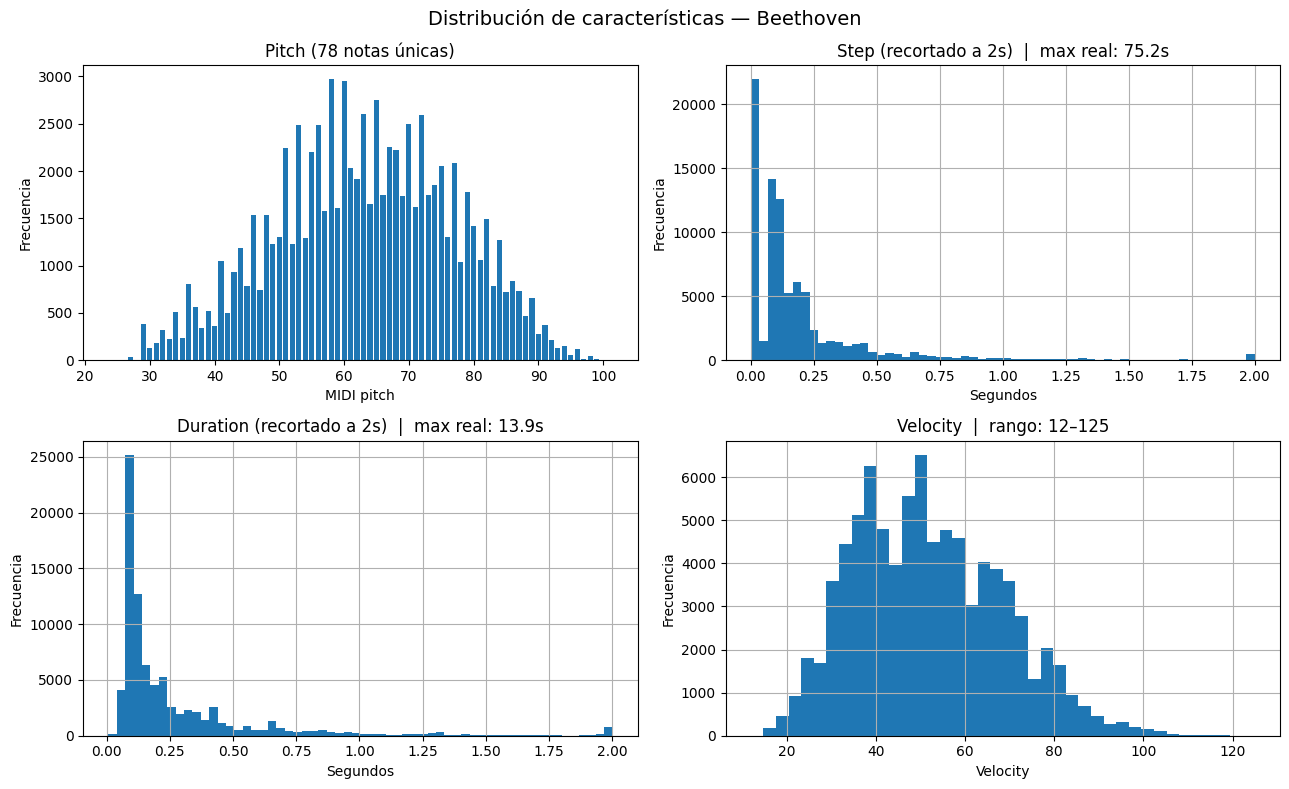


Estadísticas descriptivas:
           pitch       step   duration   velocity
count  84785.000  84785.000  84785.000  84785.000
mean      63.193      0.200      0.286     51.866
std       13.787      0.448      0.416     16.574
min       24.000      0.000      0.007     12.000
25%       53.000      0.000      0.096     39.000
50%       63.000      0.108      0.140     50.000
75%       73.000      0.213      0.323     63.000
max      101.000     75.246     13.944    125.000


In [12]:
# --- 5.3 Distribución de las 4 características ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribución de características — Beethoven', fontsize=14)

pitch_counts = df['pitch'].value_counts().sort_index()
axes[0, 0].bar(pitch_counts.index, pitch_counts.values, width=0.8)
axes[0, 0].set_title(f'Pitch ({df["pitch"].nunique()} notas únicas)')
axes[0, 0].set_xlabel('MIDI pitch')
axes[0, 0].set_ylabel('Frecuencia')

df['step'].clip(0, 2).hist(ax=axes[0, 1], bins=60, edgecolor='none')
axes[0, 1].set_title(f'Step (recortado a 2s)  |  max real: {df["step"].max():.1f}s')
axes[0, 1].set_xlabel('Segundos')
axes[0, 1].set_ylabel('Frecuencia')

df['duration'].clip(0, 2).hist(ax=axes[1, 0], bins=60, edgecolor='none')
axes[1, 0].set_title(f'Duration (recortado a 2s)  |  max real: {df["duration"].max():.1f}s')
axes[1, 0].set_xlabel('Segundos')
axes[1, 0].set_ylabel('Frecuencia')

df['velocity'].hist(ax=axes[1, 1], bins=40, edgecolor='none')
axes[1, 1].set_title(f'Velocity  |  rango: {df["velocity"].min()}–{df["velocity"].max()}')
axes[1, 1].set_xlabel('Velocity')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('\nEstadísticas descriptivas:')
print(df.describe().round(3))

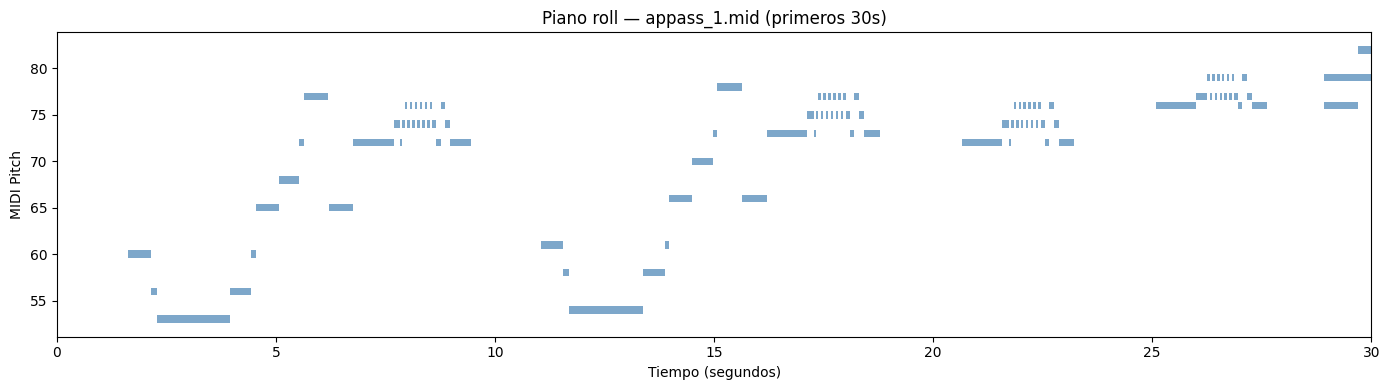

In [13]:
# --- 5.4 Piano roll de una composición de ejemplo ---
pm_example = pretty_midi.PrettyMIDI(midi_files[0])
notes_example = sorted(pm_example.instruments[0].notes, key=lambda x: x.start)

cutoff = 30
notes_plot = [n for n in notes_example if n.start < cutoff]

fig, ax = plt.subplots(figsize=(14, 4))
for note in notes_plot:
    ax.barh(note.pitch, note.end - note.start, left=note.start, height=0.8, color='steelblue', alpha=0.7)

ax.set_xlabel('Tiempo (segundos)')
ax.set_ylabel('MIDI Pitch')
ax.set_title(f'Piano roll — {os.path.basename(midi_files[0])} (primeros {cutoff}s)')
ax.set_xlim(0, cutoff)
plt.tight_layout()
plt.show()

Archivo                                # cambios   Min BPM   Max BPM   Media BPM
------------------------------------------------------------------------------
  appass_1.mid                              3825      48.0     242.6       171.8
  appass_2.mid                               700      21.0      64.0        48.2
  appass_3.mid                              2600      91.5     219.6       149.7
  beethoven_hammerklavier_1.mid             2046      21.5     138.0       107.3
  beethoven_hammerklavier_2.mid              690      18.5     241.0       135.4
  beethoven_hammerklavier_3.mid             1060      10.0      56.0        44.0
  beethoven_hammerklavier_4.mid             3355       8.5     149.0       127.9
  beethoven_les_adieux_1.mid                1029      22.8     153.0       117.0
  beethoven_les_adieux_2.mid                 296      37.5      84.4        58.4
  beethoven_les_adieux_3.mid                1172      25.7     186.7       161.6
  beethoven_opus10_1.mid      

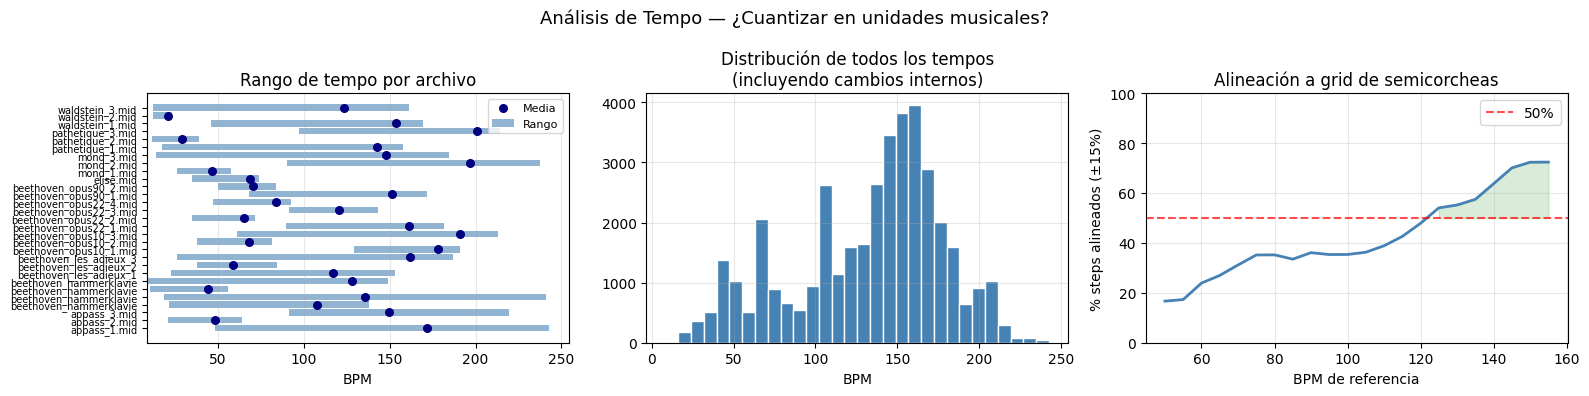


→ Si CV > 15% o alineación < 50%: los bins por cuantiles son más robustos.
→ Si CV < 15% y alineación > 60%: cuantizar en unidades musicales tiene sentido.


In [14]:
# --- 5.5 Análisis de tempo: ¿conviene cuantizar en unidades musicales? ---

# ── 1. Tempo por archivo ─────────────────────────────────────────────────
# get_tempo_changes() devuelve (times_array, tempos_bpm_array)
print(f"{'Archivo':<38} {'# cambios':>9}  {'Min BPM':>8}  {'Max BPM':>8}  {'Media BPM':>10}")
print('-' * 78)
file_tempos = []
for f in midi_files:
    pm_f = pretty_midi.PrettyMIDI(f)
    tc_times, tc_bpms = pm_f.get_tempo_changes()
    n_changes = max(0, len(tc_bpms) - 1)
    file_tempos.append(dict(
        file=os.path.basename(f),
        bpm_mean=tc_bpms.mean(),
        bpm_min=tc_bpms.min(),
        bpm_max=tc_bpms.max(),
        n_changes=n_changes
    ))
    print(f"  {os.path.basename(f):<36} {n_changes:>9}  {tc_bpms.min():>8.1f}  {tc_bpms.max():>8.1f}  {tc_bpms.mean():>10.1f}")

mean_bpms = np.array([d['bpm_mean'] for d in file_tempos])
cv = mean_bpms.std() / mean_bpms.mean() * 100
print(f"\nBPM (media por archivo) → media: {mean_bpms.mean():.1f}  std: {mean_bpms.std():.1f}  CV: {cv:.1f}%")
print(f"Cambios internos por archivo → min: {min(d['n_changes'] for d in file_tempos)}  "
      f"max: {max(d['n_changes'] for d in file_tempos)}  "
      f"media: {np.mean([d['n_changes'] for d in file_tempos]):.0f}")

# ── 2. Alineación al grid de semicorcheas ────────────────────────────────
print("\n─── Alineación al grid de semicorcheas (error relativo < 15%) ───")
all_steps_raw = df['step'].clip(0, df['step'].quantile(0.99)).values
all_steps_raw = all_steps_raw[all_steps_raw > 0.01]   # ignorar notas simultáneas

for bpm in [60, 80, 100, 120, round(mean_bpms.mean())]:
    sixteenth   = 60 / bpm / 4
    multiples   = np.round(all_steps_raw / sixteenth).clip(1, None)
    quantized   = multiples * sixteenth
    rel_error   = np.abs(all_steps_raw - quantized) / (quantized + 1e-9)
    pct_aligned = (rel_error < 0.15).mean() * 100
    print(f"  BPM {bpm:5.0f} → semicorchea = {sixteenth:.4f}s  →  {pct_aligned:.1f}% de steps alineados")

# ── 3. Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Análisis de Tempo — ¿Cuantizar en unidades musicales?', fontsize=13)

# 3a. Rango de BPM por archivo
ax = axes[0]
names = [d['file'][:22] for d in file_tempos]
mins  = [d['bpm_min']   for d in file_tempos]
maxs  = [d['bpm_max']   for d in file_tempos]
means = [d['bpm_mean']  for d in file_tempos]
y_pos = range(len(names))
ax.barh(list(y_pos), [mx - mn for mn, mx in zip(mins, maxs)], left=mins,
        color='steelblue', alpha=0.6, label='Rango')
ax.scatter(means, list(y_pos), color='navy', zorder=3, s=30, label='Media')
ax.set_yticks(list(y_pos)); ax.set_yticklabels(names, fontsize=7)
ax.set_xlabel('BPM'); ax.set_title('Rango de tempo por archivo')
ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)

# 3b. Distribución de todos los tempos internos
ax = axes[1]
all_internal = []
for f in midi_files:
    _, tc_bpms = pretty_midi.PrettyMIDI(f).get_tempo_changes()
    all_internal.extend(tc_bpms.tolist())
ax.hist(all_internal, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('BPM'); ax.set_title('Distribución de todos los tempos\n(incluyendo cambios internos)')
ax.grid(alpha=0.3)

# 3c. % de alineación a semicorchea vs BPM de referencia
ax = axes[2]
bpm_range  = np.arange(50, 160, 5)
alignments = []
for bpm in bpm_range:
    s = 60 / bpm / 4
    q = np.round(all_steps_raw / s).clip(1, None) * s
    alignments.append((np.abs(all_steps_raw - q) / (q + 1e-9) < 0.15).mean() * 100)
ax.plot(bpm_range, alignments, color='steelblue', linewidth=2)
ax.axhline(50, color='red', linestyle='--', alpha=0.7, label='50%')
ax.fill_between(bpm_range, alignments, 50,
                where=[a > 50 for a in alignments], alpha=0.15, color='green')
ax.set_xlabel('BPM de referencia'); ax.set_ylabel('% steps alineados (±15%)')
ax.set_title('Alineación a grid de semicorcheas')
ax.set_ylim(0, 100); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n→ Si CV > 15% o alineación < 50%: los bins por cuantiles son más robustos.")
print("→ Si CV < 15% y alineación > 60%: cuantizar en unidades musicales tiene sentido.")


## 6. Preparación del dataset para entrenamiento

In [15]:
# --- 6.1 Split train / test al nivel de secuencia ---
n_sequences = len(sequences)
idx_all = np.random.permutation(n_sequences)
split = int(n_sequences * 0.9)

train_seqs  = [sequences[i]      for i in idx_all[:split]]
test_seqs   = [sequences[i]      for i in idx_all[split:]]
train_names = [sequence_names[i] for i in idx_all[:split]]
test_names  = [sequence_names[i] for i in idx_all[split:]]

print(f'Total de secuencias: {n_sequences}')
print(f'  Train: {len(train_seqs)} secuencias  ({sum(len(s) for s in train_seqs):,} notas)')
print(f'  Test:  {len(test_seqs)} secuencias  ({sum(len(s) for s in test_seqs):,} notas)')
print(f'\nCanciones de TEST (el modelo NO las verá durante entrenamiento):')
for name in test_names:
    print(f'  - {name}')


# --- 6.1b Data augmentation: transposición de tono (solo train) ---
TRANSPOSE_SEMITONES = [-4, -2, -1, 1, 2, 4]   # ±1 y ±2 tonos → 7x más datos
augmented_seqs = []
for seq in train_seqs:
    for delta in TRANSPOSE_SEMITONES:
        aug = seq.copy()
        aug['pitch'] = (aug['pitch'] + delta).clip(0, 127)
        augmented_seqs.append(aug)
train_seqs = train_seqs + augmented_seqs
print(f'Train tras augmentación: {len(train_seqs)} secuencias  ({sum(len(s) for s in train_seqs):,} notas)')


Total de secuencias: 47
  Train: 42 secuencias  (77,282 notas)
  Test:  5 secuencias  (7,503 notas)

Canciones de TEST (el modelo NO las verá durante entrenamiento):
  - beethoven_hammerklavier_1.mid — inst 1
  - mond_1.mid — inst 2
  - beethoven_les_adieux_1.mid — inst 0
  - beethoven_opus22_2.mid — inst 0
  - elise.mid — inst 0
Train tras augmentación: 294 secuencias  (540,974 notas)


In [16]:
# --- 6.2 Normalización ---
# pitch  → se deja como entero (0-127) para usarlo en un Embedding
# step, duration, velocity → MinMaxScaler ajustado SOLO con datos de train
#
# IMPORTANTE: step y duration tienen outliers extremos (max ~185s, pausas entre canciones).
# Clipeamos a percentil 99 antes de normalizar para que el scaler no aplaste todo el rango.

STEP_CLIP     = pd.concat(train_seqs)['step'].quantile(0.99)
DURATION_CLIP = pd.concat(train_seqs)['duration'].quantile(0.99)
print(f'Clip step al percentil 99:     {STEP_CLIP:.4f} s')
print(f'Clip duration al percentil 99: {DURATION_CLIP:.4f} s')

scaler = MinMaxScaler()
train_clipped = pd.concat(train_seqs).copy()
train_clipped['step']     = train_clipped['step'].clip(0, STEP_CLIP)
train_clipped['duration'] = train_clipped['duration'].clip(0, DURATION_CLIP)
scaler.fit(train_clipped[['step', 'duration', 'velocity']])

def normalize_seq(seq_df, scaler, step_clip, duration_clip):
    """Devuelve un array (N, 4): [pitch_int, step_norm, duration_norm, velocity_norm]"""
    arr = seq_df.copy()
    arr['step']     = arr['step'].clip(0, step_clip)
    arr['duration'] = arr['duration'].clip(0, duration_clip)
    arr[['step', 'duration', 'velocity']] = scaler.transform(arr[['step', 'duration', 'velocity']])
    return arr.values

train_arrays = [normalize_seq(s, scaler, STEP_CLIP, DURATION_CLIP) for s in train_seqs]
test_arrays  = [normalize_seq(s, scaler, STEP_CLIP, DURATION_CLIP) for s in test_seqs]

print('\nEjemplo de una nota normalizada [pitch, step_norm, duration_norm, velocity_norm]:'  )
print(f'  {train_arrays[0][0]}')
# --- 6.2b Bins para step y duration (en espacio normalizado) ---
N_BINS = 16

all_step_norm = np.concatenate([a[:, 1] for a in train_arrays])
all_dur_norm  = np.concatenate([a[:, 2] for a in train_arrays])

step_edges_norm = np.quantile(all_step_norm, np.linspace(0, 1, N_BINS + 1))
dur_edges_norm  = np.quantile(all_dur_norm,  np.linspace(0, 1, N_BINS + 1))
step_edges_norm[-1] += 1e-9   # garantiza que el valor máximo caiga en el último bin
dur_edges_norm[-1]  += 1e-9

step_centers_norm = (step_edges_norm[:-1] + step_edges_norm[1:]) / 2
dur_centers_norm  = (dur_edges_norm[:-1]  + dur_edges_norm[1:])  / 2

print(f'\nBins step    (norm): {step_edges_norm.round(3)}')
print(f'Bins duration (norm): {dur_edges_norm.round(3)}')


Clip step al percentil 99:     1.5445 s
Clip duration al percentil 99: 1.7870 s

Ejemplo de una nota normalizada [pitch, step_norm, duration_norm, velocity_norm]:
  [4.60000000e+01 0.00000000e+00 3.85448423e-02 2.12389381e-01]

Bins step    (norm): [0.    0.    0.    0.    0.    0.053 0.059 0.062 0.068 0.076 0.096 0.116
 0.137 0.17  0.251 0.393 1.   ]
Bins duration (norm): [0.    0.038 0.046 0.047 0.049 0.054 0.056 0.063 0.074 0.09  0.108 0.128
 0.178 0.225 0.302 0.457 1.   ]


In [17]:
# --- 6.3 DataLoader ---
BLOCK_SIZE = 32   # 32 notas de contexto (~2-4 compases): captura frases musicales más largas
BATCH_SIZE = 64

class MusicDataLoader:
    def __init__(self, sequences, block_size):
        self.block_size = block_size
        self.sequences  = [torch.tensor(s, dtype=torch.float32) for s in sequences]

        self.indices = []
        for seq_idx, seq in enumerate(self.sequences):
            for start in range(len(seq) - block_size):
                self.indices.append((seq_idx, start))

        self.order    = np.random.permutation(len(self.indices))
        self.curr_pos = 0

    def get_batch(self, batch_size):
        batch_idx = self.order[self.curr_pos : self.curr_pos + batch_size]
        self.curr_pos += len(batch_idx)

        if len(batch_idx) < batch_size:
            self.curr_pos = 0
            self.order = np.random.permutation(len(self.indices))
            if len(batch_idx) == 0:
                batch_idx = self.order[:batch_size]
                self.curr_pos = batch_size

        xs, ys = [], []
        for i in batch_idx:
            seq_idx, start = self.indices[i]
            seq = self.sequences[seq_idx]
            xs.append(seq[start : start + self.block_size])
            ys.append(seq[start + self.block_size])

        return torch.stack(xs), torch.stack(ys)

    @property
    def n_examples(self):
        return len(self.indices)


train_loader = MusicDataLoader(train_arrays, block_size=BLOCK_SIZE)
test_loader  = MusicDataLoader(test_arrays,  block_size=BLOCK_SIZE)

print(f'Block size (contexto): {BLOCK_SIZE} notas')
print(f'Batch size:            {BATCH_SIZE}')
print(f'Ventanas de entrenamiento: {train_loader.n_examples:,}')
print(f'Ventanas de test:          {test_loader.n_examples:,}')

x_sample, y_sample = train_loader.get_batch(BATCH_SIZE)
print(f'\nForma de un lote:')
print(f'  x: {tuple(x_sample.shape)}  -> (batch, contexto, features)')
print(f'  y: {tuple(y_sample.shape)}  -> (batch, features)')
print(f'\nRango de step normalizado en un batch: [{x_sample[:,:,1].min():.3f}, {x_sample[:,:,1].max():.3f}]')

Block size (contexto): 32 notas
Batch size:            64
Ventanas de entrenamiento: 531,566
Ventanas de test:          7,343

Forma de un lote:
  x: (64, 32, 4)  -> (batch, contexto, features)
  y: (64, 4)  -> (batch, features)

Rango de step normalizado en un batch: [0.000, 1.000]


## 7. Modelo LSTM

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

VOCAB_SIZE  = 128   # notas MIDI posibles (0-127)
EMBED_DIM   = 64    # dimensión del embedding de pitch
HIDDEN_SIZE = 512   # tamaño del estado oculto del LSTM
NUM_LAYERS  = 3     # capas LSTM apiladas
DROPOUT     = 0.3   # dropout entre capas LSTM
DROPOUT_OUT = 0.3   # dropout antes de las cabezas de predicción

class MusicLSTM(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Embedding para pitch (variable categórica, 128 valores posibles)
        self.pitch_embedding = torch.nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        # LSTM: recibe [embed_pitch(64) + step(1) + duration(1) + velocity(1)] = 67 features
        self.lstm = torch.nn.LSTM(
            input_size  = EMBED_DIM + 3,
            hidden_size = HIDDEN_SIZE,
            num_layers  = NUM_LAYERS,
            batch_first = True,
            dropout     = DROPOUT
        )
        # Dropout antes de las cabezas (regulariza el vector de salida del LSTM)
        self.dropout_out = torch.nn.Dropout(DROPOUT_OUT)
        # Cabeza pitch → 128 logits (CrossEntropy)
        self.head_pitch    = torch.nn.Linear(HIDDEN_SIZE, VOCAB_SIZE)
        # Cabezas step y duration → N_BINS logits (CrossEntropy sobre bins)
        self.head_step     = torch.nn.Linear(HIDDEN_SIZE, N_BINS)
        self.head_duration = torch.nn.Linear(HIDDEN_SIZE, N_BINS)
        # Cabeza velocity → 1 valor (MAE)
        self.head_velocity = torch.nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, x):
        pitch_idx = x[:, :, 0].long()                               # (batch, block_size)
        numerics  = x[:, :, 1:]                                     # (batch, block_size, 3)
        pitch_emb = self.pitch_embedding(pitch_idx)                 # (batch, block_size, 64)
        lstm_in   = torch.cat([pitch_emb, numerics], dim=-1)       # (batch, block_size, 67)
        lstm_out, _ = self.lstm(lstm_in)                            # (batch, block_size, 512)
        last_hidden = self.dropout_out(lstm_out[:, -1, :])          # (batch, 512) + dropout
        pitch_logits  = self.head_pitch(last_hidden)
        step_logits   = self.head_step(last_hidden)
        dur_logits    = self.head_duration(last_hidden)
        velocity_pred = self.head_velocity(last_hidden).squeeze(1)
        return pitch_logits, step_logits, dur_logits, velocity_pred


model = MusicLSTM().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parámetros totales: {n_params:,}')
print(model)


Dispositivo: cuda
Parámetros totales: 5,483,169
MusicLSTM(
  (pitch_embedding): Embedding(128, 64)
  (lstm): LSTM(67, 512, num_layers=3, batch_first=True, dropout=0.3)
  (dropout_out): Dropout(p=0.3, inplace=False)
  (head_pitch): Linear(in_features=512, out_features=128, bias=True)
  (head_step): Linear(in_features=512, out_features=16, bias=True)
  (head_duration): Linear(in_features=512, out_features=16, bias=True)
  (head_velocity): Linear(in_features=512, out_features=1, bias=True)
)


## 8. Entrenamiento

In [19]:
# --- 8.1 Función de pérdida compuesta ---
ce_loss  = torch.nn.CrossEntropyLoss()
mae_loss = torch.nn.L1Loss()

LAMBDA_VELOCITY = 10.0   # step y duration ahora usan CE (misma escala que pitch)

# Bordes de bins como tensores (se mueven al device en cada call)
step_edges_t = torch.tensor(step_edges_norm[1:], dtype=torch.float32)
dur_edges_t  = torch.tensor(dur_edges_norm[1:],  dtype=torch.float32)

def composed_loss(pitch_logits, step_logits, dur_logits, velocity_pred, y):
    """y: (batch, 4) — [pitch(int), step_norm, duration_norm, velocity_norm]"""
    # Convertir valores normalizados de step/duration a índice de bin
    step_bins = torch.bucketize(y[:, 1].contiguous(), step_edges_t.to(y.device)).clamp(0, N_BINS - 1)
    dur_bins  = torch.bucketize(y[:, 2].contiguous(), dur_edges_t.to(y.device)).clamp(0, N_BINS - 1)

    l_pitch    = ce_loss(pitch_logits, y[:, 0].long())
    l_step     = ce_loss(step_logits,  step_bins)
    l_duration = ce_loss(dur_logits,   dur_bins)
    l_velocity = mae_loss(velocity_pred, y[:, 3])
    total = l_pitch + l_step + l_duration + LAMBDA_VELOCITY * l_velocity
    return total, l_pitch, l_step, l_duration, l_velocity


@torch.no_grad()
def estimate_loss(model, train_loader, test_loader, eval_iters=10):
    """Estima loss total y componentes individuales sobre N batches aleatorios."""
    model.eval()
    keys = ['total', 'pitch', 'step', 'duration', 'velocity']
    results = {}
    for name, loader in [('train', train_loader), ('test', test_loader)]:
        accum = {k: 0.0 for k in keys}
        for _ in range(eval_iters):
            x, y = loader.get_batch(BATCH_SIZE)
            x, y = x.to(device), y.to(device)
            total, lp, ls, ld, lv = composed_loss(*model(x), y)
            accum['total']    += total.item()
            accum['pitch']    += lp.item()
            accum['step']     += ls.item()
            accum['duration'] += ld.item()
            accum['velocity'] += lv.item()
        results[name] = {k: accum[k] / eval_iters for k in keys}
    model.train()
    return results


In [20]:
LR           = 0.0003
WEIGHT_DECAY = 0.0001
EPOCHS       = 20
steps_per_epoch = train_loader.n_examples // BATCH_SIZE
MAX_STEPS       = EPOCHS * steps_per_epoch

# --- Early stopping ---
ES_PATIENCE = 40   # evaluaciones sin mejora antes de parar (= 2000 pasos)
ES_MIN_DELTA = 0.001  # mejora mínima que cuenta como progreso
best_test_loss = float('inf')
es_counter     = 0
best_model_state = None

print(f'Pasos por época:  {steps_per_epoch}')
print(f'Total de pasos:   {MAX_STEPS}')
print(f'Early stop si no mejora en {ES_PATIENCE} evaluaciones ({ES_PATIENCE*100} pasos)')

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

log = {split: {k: [] for k in ['total','pitch','step','duration','velocity']}
       for split in ['train','test']}

model.train()
for step in range(MAX_STEPS):
    x, y = train_loader.get_batch(BATCH_SIZE)
    x, y = x.to(device), y.to(device)

    loss, *_ = composed_loss(*model(x), y)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if (step + 1) % 100 == 0 or step == 0 or step == MAX_STEPS - 1:
        res = estimate_loss(model, train_loader, test_loader)
        for split in ['train', 'test']:
            for k in log[split]:
                log[split][k].append(res[split][k])
        scheduler.step(res['test']['total'])

        # Early stopping
        test_loss = res['test']['total']
        if test_loss < best_test_loss - ES_MIN_DELTA:
            best_test_loss   = test_loss
            es_counter       = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            es_counter += 1

        print(f"Step {step+1:5d}/{MAX_STEPS} "
              f"— Train: {res['train']['total']:.3f} "
              f"(pitch={res['train']['pitch']:.2f} "
              f"step={res['train']['step']:.3f} "
              f"dur={res['train']['duration']:.3f} "
              f"vel={res['train']['velocity']:.3f}) "
              f"| Test: {test_loss:.3f}  "
              f"[ES {es_counter}/{ES_PATIENCE}]")

        if es_counter >= ES_PATIENCE:
            print(f'\nEarly stopping en step {step+1}. Mejor test loss: {best_test_loss:.4f}')
            model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
            print('Modelo restaurado al mejor checkpoint.')
            break

else:
    print(f'\nEntrenamiento completado. Mejor test loss: {best_test_loss:.4f}')
    if best_model_state:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})


Pasos por época:  8305
Total de pasos:   166100
Early stop si no mejora en 40 evaluaciones (4000 pasos)
Step     1/166100 — Train: 13.090 (pitch=4.85 step=2.778 dur=2.773 vel=0.269) | Test: 12.766  [ES 0/40]
Step   100/166100 — Train: 10.256 (pitch=4.15 step=2.445 dur=2.769 vel=0.090) | Test: 10.160  [ES 0/40]
Step   200/166100 — Train: 10.101 (pitch=4.04 step=2.456 dur=2.760 vel=0.084) | Test: 10.042  [ES 0/40]
Step   300/166100 — Train: 9.816 (pitch=3.83 step=2.413 dur=2.752 vel=0.082) | Test: 9.903  [ES 0/40]
Step   400/166100 — Train: 9.562 (pitch=3.70 step=2.389 dur=2.741 vel=0.073) | Test: 9.813  [ES 0/40]
Step   500/166100 — Train: 9.332 (pitch=3.55 step=2.380 dur=2.713 vel=0.069) | Test: 9.413  [ES 0/40]
Step   600/166100 — Train: 9.185 (pitch=3.53 step=2.353 dur=2.722 vel=0.058) | Test: 9.322  [ES 0/40]
Step   700/166100 — Train: 9.070 (pitch=3.41 step=2.316 dur=2.697 vel=0.065) | Test: 9.509  [ES 1/40]
Step   800/166100 — Train: 9.071 (pitch=3.37 step=2.345 dur=2.664 vel=0.07

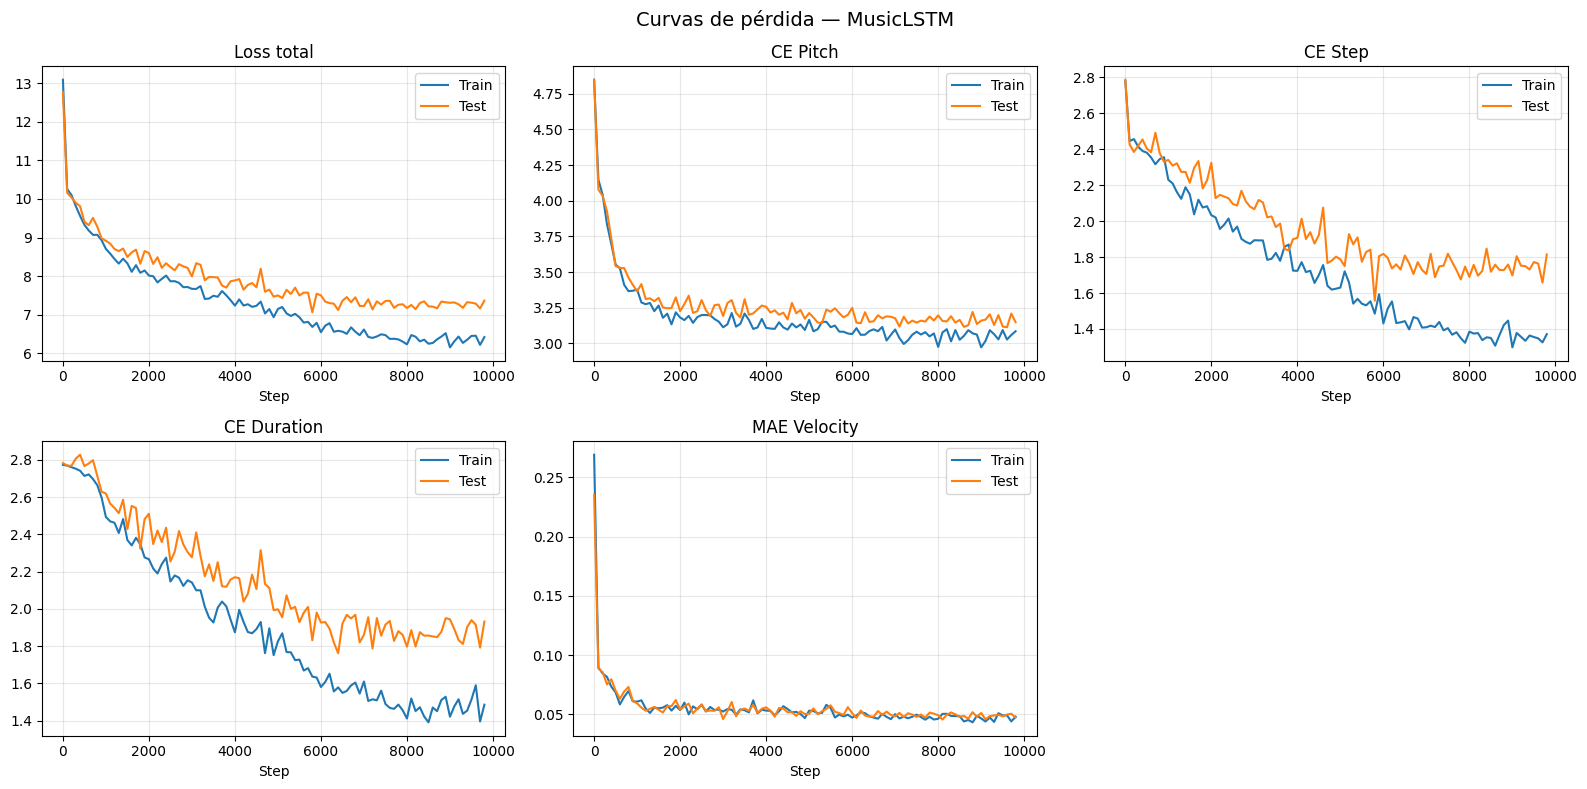


Valores finales (último checkpoint):
                Train     Test
total          6.4214   7.3673
pitch          3.0840   3.1482
step           1.3710   1.8141
duration       1.4858   1.9320
velocity       0.0481   0.0473


In [21]:
# --- 8.3 Curvas de pérdida: total + componentes ---
steps_logged = ([1] + list(range(100, MAX_STEPS, 100)) + [MAX_STEPS])[:len(log['train']['total'])]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Curvas de pérdida — MusicLSTM', fontsize=14)

componentes = [
    ('total',    'Loss total',        axes[0, 0]),
    ('pitch',    'CE Pitch',          axes[0, 1]),
    ('step',     'CE Step',          axes[0, 2]),
    ('duration', 'CE Duration',      axes[1, 0]),
    ('velocity', 'MAE Velocity',      axes[1, 1]),
]

for key, title, ax in componentes:
    ax.plot(steps_logged, log['train'][key], label='Train')
    ax.plot(steps_logged, log['test'][key],  label='Test')
    ax.set_title(title)
    ax.set_xlabel('Step')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[1, 2].axis('off')  # celda vacía (6to subplot)
plt.tight_layout()
plt.show()

# Tabla resumen final
print('\nValores finales (último checkpoint):')
print(f'{"":12} {"Train":>8} {"Test":>8}')
for key in ['total','pitch','step','duration','velocity']:
    print(f'{key:12} {log["train"][key][-1]:8.4f} {log["test"][key][-1]:8.4f}')


## 9. Generación y evaluación

In [22]:
@torch.no_grad()
def generate_notes(model, seed_seq, n_notes=200, temperature=1.0):
    """
    Genera n_notes notas a partir de una secuencia semilla del conjunto de test.
    temperature: >1 más variedad, <1 más conservador.
    Retorna un DataFrame con las notas desnormalizadas.
    """
    model.eval()
    context = torch.tensor(seed_seq[-BLOCK_SIZE:], dtype=torch.float32).unsqueeze(0).to(device)

    generated = []
    for _ in range(n_notes):
        pitch_logits, step_logits, dur_logits, velocity_pred = model(context)

        # Pitch: muestreo con temperatura
        probs = torch.softmax(pitch_logits[0] / temperature, dim=-1)
        pitch = torch.multinomial(probs, num_samples=1).item()

        # Step: muestreo con temperatura sobre bins → centro del bin (valor normalizado)
        step_probs = torch.softmax(step_logits[0] / temperature, dim=-1)
        step_bin   = torch.multinomial(step_probs, num_samples=1).item()
        step       = float(step_centers_norm[step_bin])

        # Duration: igual
        dur_probs  = torch.softmax(dur_logits[0] / temperature, dim=-1)
        dur_bin    = torch.multinomial(dur_probs, num_samples=1).item()
        duration   = float(dur_centers_norm[dur_bin])

        velocity = velocity_pred[0].item()

        generated.append([pitch, step, duration, velocity])

        # Deslizar la ventana de contexto
        new_note = torch.tensor([[pitch, step, duration, velocity]], dtype=torch.float32).unsqueeze(0).to(device)
        context  = torch.cat([context[:, 1:, :], new_note], dim=1)

    gen_array = np.array(generated)

    # Desnormalizar step, duration, velocity
    gen_denorm = gen_array.copy()
    gen_denorm[:, 1:] = scaler.inverse_transform(gen_array[:, 1:])

    # Clipear a rangos válidos
    gen_denorm[:, 0] = np.clip(gen_denorm[:, 0], 0, 127).astype(int)
    gen_denorm[:, 1] = np.clip(gen_denorm[:, 1], 0, None)
    gen_denorm[:, 2] = np.clip(gen_denorm[:, 2], 0.01, None)
    gen_denorm[:, 3] = np.clip(gen_denorm[:, 3], 1, 127)

    return pd.DataFrame(gen_denorm, columns=['pitch', 'step', 'duration', 'velocity']).astype(
        {'pitch': int, 'velocity': int}
    )


In [23]:
if COLAB:
    GENERATED_DIR = '/content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated'
else:
    GENERATED_DIR = './generated'

os.makedirs(GENERATED_DIR, exist_ok=True)

def notes_to_midi(df_notes, output_path, instrument_name='Acoustic Grand Piano'):
    pm_out   = pretty_midi.PrettyMIDI()
    program  = pretty_midi.instrument_name_to_program(instrument_name)
    inst_out = pretty_midi.Instrument(program=program)
    current_start = 0.0
    for _, row in df_notes.iterrows():
        current_start += float(row['step'])
        note = pretty_midi.Note(
            velocity = int(row['velocity']),
            pitch    = int(row['pitch']),
            start    = current_start,
            end      = current_start + float(row['duration'])
        )
        inst_out.notes.append(note)
    pm_out.instruments.append(inst_out)
    pm_out.write(output_path)

def denormalize_seed(seed_array):
    """Convierte el seed normalizado a DataFrame con valores reales."""
    arr = seed_array.copy()
    arr[:, 1:] = scaler.inverse_transform(arr[:, 1:])  # desnormalizar step/duration/velocity
    arr[:, 0] = np.clip(arr[:, 0], 0, 127).astype(int)
    arr[:, 1] = np.clip(arr[:, 1], 0, None)
    arr[:, 2] = np.clip(arr[:, 2], 0.01, None)
    arr[:, 3] = np.clip(arr[:, 3], 1, 127)
    return pd.DataFrame(arr, columns=['pitch', 'step', 'duration', 'velocity']).astype(
        {'pitch': int, 'velocity': int}
    )

for i, temp in enumerate([0.5, 0.7, 0.9], start=1):
    seed      = test_arrays[i % len(test_arrays)][:BLOCK_SIZE]
    df_seed   = denormalize_seed(seed)          # 32 notas reales (seed)
    df_gen    = generate_notes(model, seed, n_notes=200, temperature=temp)
    df_full   = pd.concat([df_seed, df_gen], ignore_index=True)  # seed + generado
    filepath  = os.path.join(GENERATED_DIR, f'beethoven_gen_{i}.mid')
    notes_to_midi(df_full, filepath)
    print(f'Guardado: {os.path.basename(filepath)}  ({len(df_seed)} seed + {len(df_gen)} generadas)')

print(f'\nArchivos MIDI generados en: {GENERATED_DIR}')

if COLAB:
    from google.colab import files
    for i in range(1, 4):
        fpath = os.path.join(GENERATED_DIR, f'beethoven_gen_{i}.mid')
        files.download(fpath)
        print(f'Descargando: {os.path.basename(fpath)}')


Guardado: beethoven_gen_1.mid  (32 seed + 200 generadas)
Guardado: beethoven_gen_2.mid  (32 seed + 200 generadas)
Guardado: beethoven_gen_3.mid  (32 seed + 200 generadas)

Archivos MIDI generados en: /content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_gen_1.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_gen_2.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_gen_3.mid


## 10. Evaluación: generado vs real

In [24]:
# --- 10.1 Cargar archivo generado y secuencia real de referencia ---

# Generado: leer el primer archivo MIDI generado
pm_gen = pretty_midi.PrettyMIDI(os.path.join(GENERATED_DIR, 'beethoven_gen_1.mid'))
notes_gen_raw = sorted(pm_gen.instruments[0].notes, key=lambda n: n.start)

# Reconstruir DataFrame del generado desde el MIDI
rows_gen = []
prev_start = None
for n in notes_gen_raw:
    step = n.start - prev_start if prev_start is not None else 0.0
    rows_gen.append({'pitch': n.pitch, 'step': step, 'duration': n.end - n.start, 'velocity': n.velocity})
    prev_start = n.start
df_gen = pd.DataFrame(rows_gen)

# Real: la secuencia semilla usada para generar (test_seqs[1])
seq_real = test_seqs[1 % len(test_seqs)].reset_index(drop=True)

# Las primeras BLOCK_SIZE notas fueron el contexto (seed) → el modelo generó desde BLOCK_SIZE en adelante
# Comparamos el generado contra las notas reales que "debería haber seguido"
df_real_seed = seq_real.iloc[:BLOCK_SIZE]                        # notas 0-(BLOCK_SIZE-1): contexto dado
df_real_next = seq_real.iloc[BLOCK_SIZE:BLOCK_SIZE + 200]        # notas BLOCK_SIZE+: continuación real
df_real_next = df_real_next.reset_index(drop=True)

print(f'Notas de contexto (seed):          {len(df_real_seed)}')
print(f'Notas reales de referencia ({BLOCK_SIZE}+):  {len(df_real_next)}')
print(f'Notas generadas:                   {len(df_gen)}')
print()
print('Las notas reales de referencia son las que el modelo debería haber "continuado".')
print('El modelo no debe reproducirlas exactamente, sino generar música de estilo similar.\n')

# Estadísticas comparativas
stats = pd.DataFrame({
    'pitch_mean':    [df_gen['pitch'].mean(),    df_real_next['pitch'].mean()],
    'pitch_std':     [df_gen['pitch'].std(),     df_real_next['pitch'].std()],
    'step_mean':     [df_gen['step'].mean(),     df_real_next['step'].mean()],
    'step_std':      [df_gen['step'].std(),      df_real_next['step'].std()],
    'duration_mean': [df_gen['duration'].mean(), df_real_next['duration'].mean()],
    'velocity_mean': [df_gen['velocity'].mean(), df_real_next['velocity'].mean()],
}, index=['Generado', 'Real (ref)']).T.round(4)

print('Comparación estadística (Generado vs continuación real):')
print(stats)

Notas de contexto (seed):          32
Notas reales de referencia (32+):  185
Notas generadas:                   232

Las notas reales de referencia son las que el modelo debería haber "continuado".
El modelo no debe reproducirlas exactamente, sino generar música de estilo similar.

Comparación estadística (Generado vs continuación real):
               Generado  Real (ref)
pitch_mean      49.5259     41.5081
pitch_std        5.3208      6.9775
step_mean        0.5960      1.6374
step_std         0.5741      2.2960
duration_mean    1.0524      3.2277
velocity_mean   38.4009     43.5297


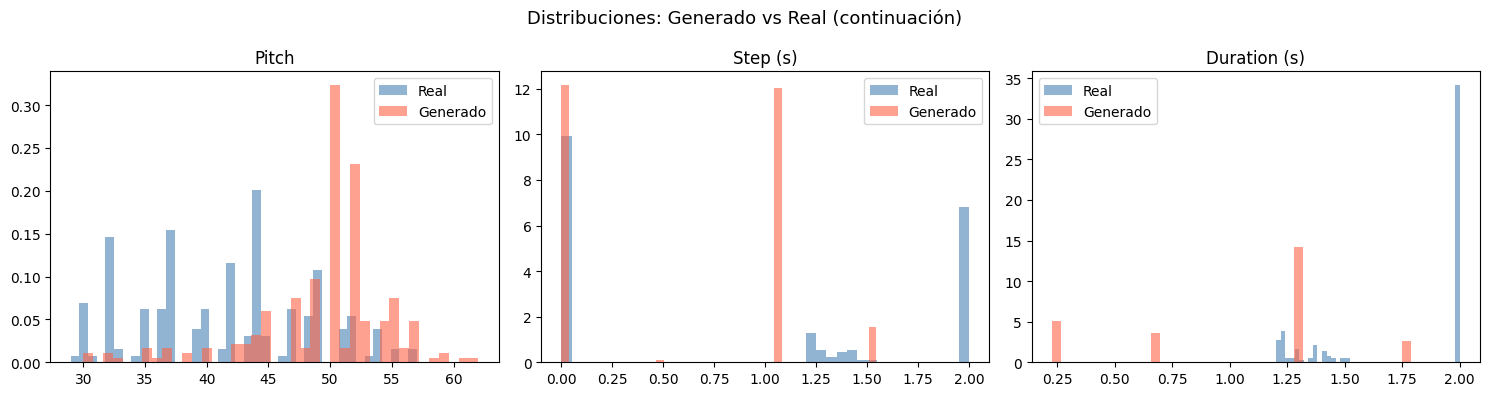

In [25]:
# --- 10.2 Distribuciones generado vs real ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribuciones: Generado vs Real (continuación)', fontsize=13)

for ax, col, label, clip_val in [
    (axes[0], 'pitch',    'Pitch',       None),
    (axes[1], 'step',     'Step (s)',    2.0),
    (axes[2], 'duration', 'Duration (s)', 2.0),
]:
    gen_vals  = df_gen[col].clip(0, clip_val)       if clip_val else df_gen[col]
    real_vals = df_real_next[col].clip(0, clip_val) if clip_val else df_real_next[col]
    ax.hist(real_vals, bins=40, alpha=0.6, label='Real',     density=True, color='steelblue')
    ax.hist(gen_vals,  bins=40, alpha=0.6, label='Generado', density=True, color='tomato')
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()

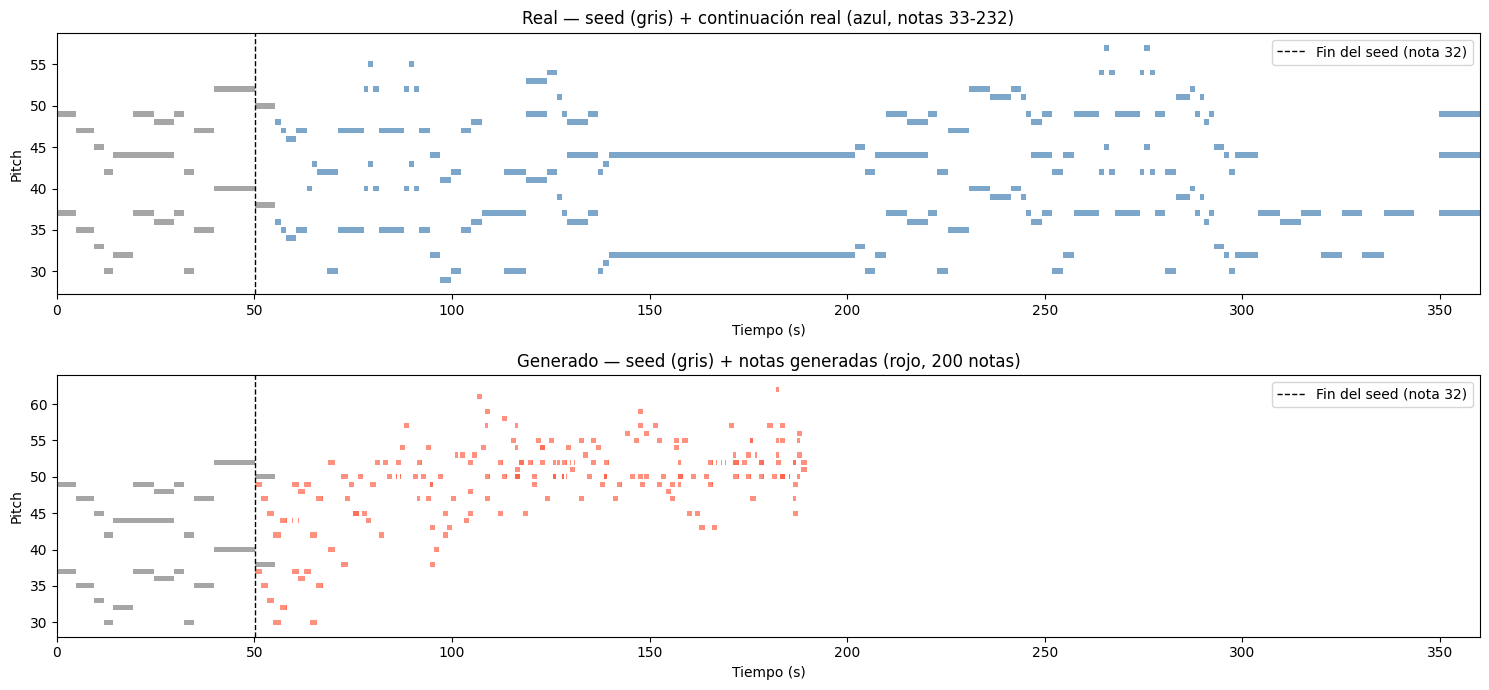

Step promedio real (ref):     1.6374 s
Step promedio generado:       0.5960 s
Ratio (gen/real):             0.36x  ← más rápido


In [26]:
# --- 10.3 Piano roll: seed + generado vs seed + continuación real ---
# Ambos gráficos comparten la misma escala de tiempo para ser comparables.
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

def plot_roll(ax, df, color, offset_t=0.0):
    t = offset_t
    for _, row in df.iterrows():
        t += row['step']
        ax.barh(row['pitch'], row['duration'], left=t, height=0.7, color=color, alpha=0.7)
    return t

seed_end = df_real_seed['step'].sum()

# Calcular el rango de tiempo máximo entre ambos para igualar escala
t_real = seed_end + df_real_next['step'].sum()
t_gen  = seed_end + df_gen['step'].sum()
x_max  = max(t_real, t_gen) * 1.02

# Arriba: seed (gris) + continuación real (azul)
plot_roll(axes[0], df_real_seed, color='gray')
plot_roll(axes[0], df_real_next, color='steelblue', offset_t=seed_end)
axes[0].axvline(seed_end, color='black', linestyle='--', linewidth=1, label=f'Fin del seed (nota {BLOCK_SIZE})')
axes[0].set_title(f'Real — seed (gris) + continuación real (azul, notas {BLOCK_SIZE+1}-{BLOCK_SIZE+200})')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Pitch')
axes[0].set_xlim(0, x_max)
axes[0].legend()

# Abajo: seed (gris) + notas generadas (rojo)
plot_roll(axes[1], df_real_seed, color='gray')
plot_roll(axes[1], df_gen, color='tomato', offset_t=seed_end)
axes[1].axvline(seed_end, color='black', linestyle='--', linewidth=1, label=f'Fin del seed (nota {BLOCK_SIZE})')
axes[1].set_title(f'Generado — seed (gris) + notas generadas (rojo, 200 notas)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Pitch')
axes[1].set_xlim(0, x_max)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Step promedio real (ref):     {df_real_next["step"].mean():.4f} s')
print(f'Step promedio generado:       {df_gen["step"].mean():.4f} s')
ratio = df_gen['step'].mean() / df_real_next['step'].mean() if df_real_next['step'].mean() > 0 else float('inf')
print(f'Ratio (gen/real):             {ratio:.2f}x  {"← más rápido" if ratio < 1 else "← más lento" if ratio > 1 else "← igual"}')
